# 01 - Wine Classification System (k-NN)
**Owner:** Dennis  |  **Dataset:** `data/wine.csv`  |  **Branch:** `feature/wine-classification`

Goal: classify a wine's cultivar from its chemical profile using k-NN,
optimized with PCA and GridSearchCV.


## Rubric checklist
- [ ] Inspect for missing values, standardize numeric features
- [ ] Convert categorical target labels to numeric
- [ ] Apply PCA retaining 95% variance
- [ ] Use GridSearchCV to find the best k and distance metric
- [ ] Train k-NN with the best parameters
- [ ] Report the classification report + accuracy score


# Wine Classification System

### DataVine Analytics — Summative Lab

This project develops a machine learning classification system that predicts wine classes based on their chemical properties. The workflow includes data preparation, feature standardization, Principal Component Analysis (PCA), k-Nearest Neighbors (k-NN) classification and hyperparameter tuning using GridSearchCV.


In [102]:
# import the libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dataset Preparation

In [103]:
df = pd.read_csv("../data/wine.csv")

In [104]:
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [105]:
df.shape

(178, 14)

In [106]:
# Generate descriptive statistics for all numerical columns
df.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


The descriptive statistics show that the dataset contains 178 observations. The predictor variables have substantially different numerical ranges. For example, Alcohol ranges from 11.03 to 14.83, while Proline ranges from 278 to 1680. This difference in scale indicates that feature standardization will be necessary before applying PCA and k-NN.

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


All predictor variables are numerical and they are suitable for standardization, PCA and k-NN classification. 

### Target Encoding

The target variable `Wine` is already numerically encoded into three classes (1, 2, and 3), so no additional categorical encoding is required.



In [108]:
# Count missing values in each column
df.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [109]:
# Count duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [110]:
# Count the number of observations in each wine class
df["Wine"].value_counts().sort_index()

Wine
1    59
2    71
3    48
Name: count, dtype: int64

The target variable contains three wine classes. Class 1 contains 59 observations, Class 2 contains 71 observations and Class 3 contains 48 observations.

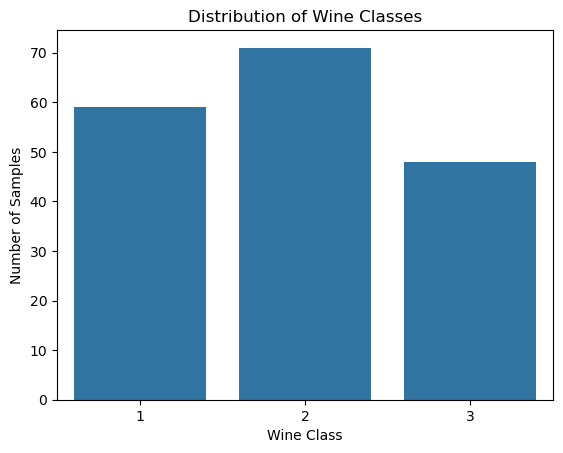

In [111]:
# Visualize the number of observations in each wine class
sns.countplot(x="Wine", data=df)

plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")

plt.show()

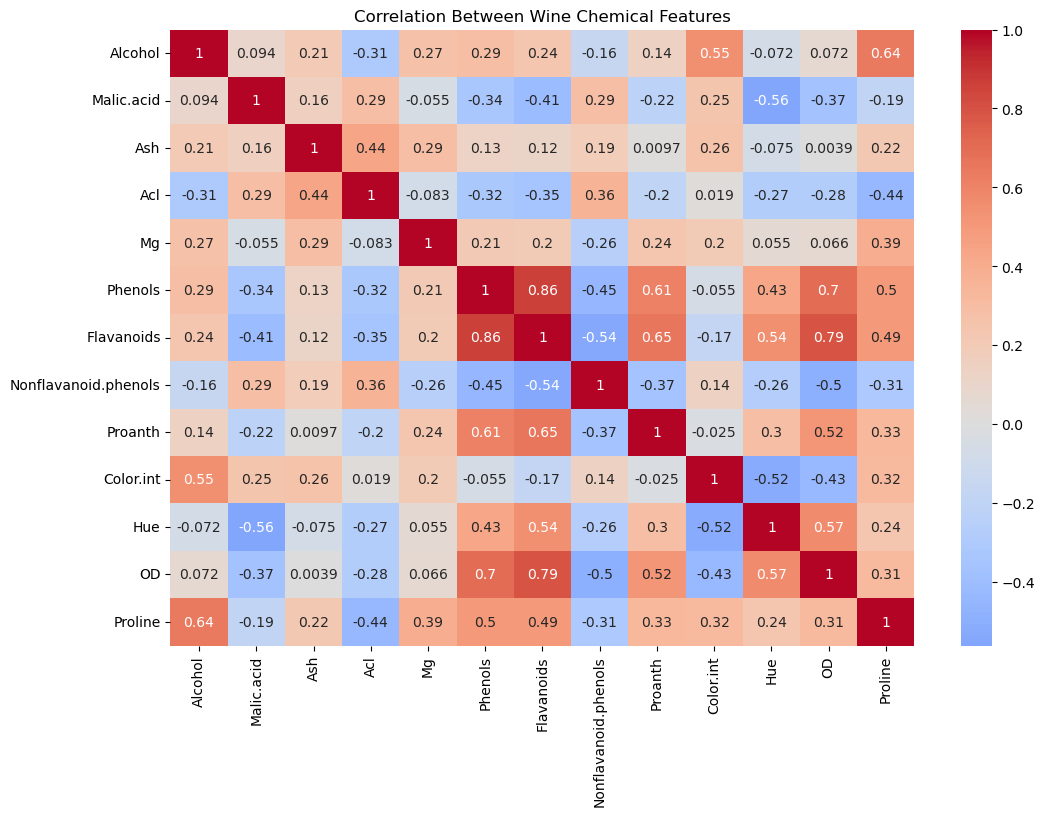

In [112]:
# check correlation between the different features
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.drop(columns="Wine").corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Wine Chemical Features")
plt.show()

In [113]:
# Separate the predictor variables from the target variable
X = df.drop(columns="Wine")

# Store the target variable separately
y = df["Wine"]

In [114]:
# Check the dimensions of the feature matrix and target vector
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (178, 13)
Target (y): (178,)


## 2. Train-Test Split

In [115]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# stratify - ensures that the three wine classes maintain approximately the same proportions in the training and testing sets.

In [116]:
# Check the dimensions of the training and testing datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (142, 13)
Testing features: (36, 13)
Training target: (142,)
Testing target: (36,)


In [117]:
# Check the distribution of wine classes in the training data
print("Training class distribution:")
print(y_train.value_counts().sort_index())

# Check the distribution of wine classes in the testing data
print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
Wine
1    47
2    57
3    38
Name: count, dtype: int64

Testing class distribution:
Wine
1    12
2    14
3    10
Name: count, dtype: int64


## 3. Feature Standardization

In [118]:
# Create a StandardScaler object
scaler = StandardScaler()

In [119]:
# Learn the mean and standard deviation of each feature using only the training data
scaler.fit(X_train)

# Transform the training data using the scaling parameters learned from X_train
X_train_scaled = scaler.transform(X_train)

In [120]:
# Transform the test data using the SAME scaling parameters learned from the training data
X_test_scaled = scaler.transform(X_test)

In [121]:
# Convert the scaled training data back to a DataFrame so we can inspect the standardized values
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_train_scaled_df.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
36,0.385801,-0.637871,1.776668,-1.224532,0.696430,0.526865,0.732292,-0.169549,-0.415783,-0.167467,0.624378,0.252908,0.467725
30,0.948519,-0.765445,1.253174,0.853284,0.091785,1.172795,1.333181,-0.590457,1.349742,0.305303,1.067155,0.151048,1.815768
26,0.523354,-0.519409,0.954034,-1.046433,-0.445678,0.930572,1.006382,-0.169549,-0.260002,-0.081509,-0.128343,0.893172,1.516203
12,0.973529,-0.555859,0.168793,-1.076116,-0.714409,0.526865,0.816627,-0.590457,0.363125,0.262324,0.890044,0.427526,1.932265
148,0.435820,0.820120,0.056615,0.556453,-0.512860,-0.555068,-1.291756,0.756449,-0.606183,1.474335,-1.766619,-1.435059,-0.297831


In [122]:
# Check that the standardized features have means close to zero
X_train_scaled_df.mean()

Alcohol                 1.100841e-15
Malic.acid              1.376051e-16
Ash                    -2.339287e-15
Acl                     5.269650e-16
Mg                      2.814650e-17
Phenols                -2.501911e-16
Flavanoids             -1.751338e-16
Nonflavanoid.phenols   -3.752867e-17
Proanth                 1.626242e-16
Color.int               8.131211e-17
Hue                    -9.507262e-16
OD                     -2.877198e-16
Proline                -1.751338e-16
dtype: float64

In [123]:
# Check that the standardized features have standard deviations close to one
X_train_scaled_df.std()

Alcohol                 1.00354
Malic.acid              1.00354
Ash                     1.00354
Acl                     1.00354
Mg                      1.00354
Phenols                 1.00354
Flavanoids              1.00354
Nonflavanoid.phenols    1.00354
Proanth                 1.00354
Color.int               1.00354
Hue                     1.00354
OD                      1.00354
Proline                 1.00354
dtype: float64

## 4. Principal Component Analysis (PCA)
PCA transforms these features into a smaller number of new components while retaining as much information as possible.

In [124]:
# Create PCA to retain at least 95% of the variance
pca = PCA(n_components=0.95)

# Learn the principal components from the training data
pca.fit(X_train_scaled)

# Transform the training data
X_train_pca = pca.transform(X_train_scaled)

# Transform the test data using the same PCA model
X_test_pca = pca.transform(X_test_scaled)

In [125]:
# Display the original number of features
print("Original number of features:", X_train.shape[1])

# Display the number of principal components retained
print("Number of principal components:", pca.n_components_)

# Display the total variance retained
print("Total variance retained:", pca.explained_variance_ratio_.sum())

Original number of features: 13
Number of principal components: 10
Total variance retained: 0.9624355601767975


In [126]:
# Calculate the cumulative variance explained by the retained components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

cumulative_variance

array([0.35792104, 0.55062776, 0.66082611, 0.73354887, 0.80076806,
       0.85208748, 0.89586171, 0.92087024, 0.94366454, 0.96243556])

In [127]:
# Check the dimensions after PCA
print("Training data after PCA:", X_train_pca.shape)
print("Testing data after PCA:", X_test_pca.shape)

Training data after PCA: (142, 10)
Testing data after PCA: (36, 10)


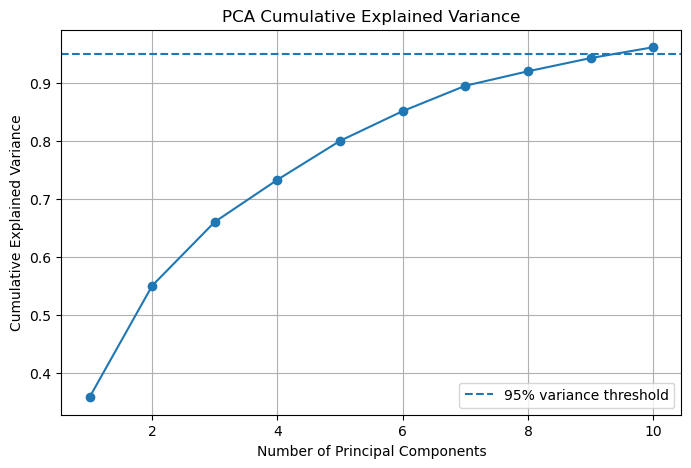

In [128]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative variance
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance threshold"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid()
plt.show()

PCA reduced the original 13 features to 10 principal components while retaining 96.24% of the total variance. Nine components retained only 94.37%, which was below the required 95% threshold so 10 components were retained.

## 5. k-NN Classification and Hyperparameter Tuning

In [129]:
# Import k-NN classifier
from sklearn.neighbors import KNeighborsClassifier

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Create the k-NN model
knn = KNeighborsClassifier()

# Define the parameters to test
param_grid = {
    "n_neighbors": range(1, 21),
    "metric": ["euclidean", "manhattan"]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

# Train and evaluate all parameter combinations
grid_search.fit(X_train_pca, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': range(1, 21)}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,18


In [130]:
# Display the best k value and distance metric
print("Best parameters:", grid_search.best_params_)

# Display the best cross-validation accuracy
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 18}
Best cross-validation accuracy: 0.9790640394088669


### 5.1 Train the optimized k-NN Model

In [131]:
# Get the best k-NN model found by GridSearchCV
best_knn = grid_search.best_estimator_

# Train the best model on the PCA transformed training data
best_knn.fit(X_train_pca, y_train)

,n_neighbors,18
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [132]:
# Use the trained model to predict wine classes
y_pred = best_knn.predict(X_test_pca)

## 6. Model Evaluation

In [133]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Calculate the test accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Test Accuracy:", accuracy)

Test Accuracy: 1.0


### 6.1 Classification Report

In [134]:
# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



The optimized k-NN model achieved an accuracy of 100% on the 36 observations in the test set. Precision, recall and F1-score were all 1 for each of the three wine classes. This indicates that all 12 Class 1 wines, 14 Class 2 wines and 10 Class 3 wines were correctly classified with no false positive or false negative predictions.

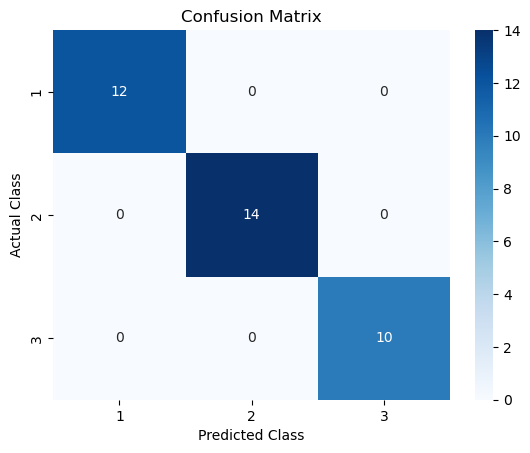

In [135]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

### 7. Conclusion

The Wine Classification model successfully demonstrated how machine learning can be used to classify wines based on their chemical properties. The dataset was inspected and prepared. There were  no missing values or duplicate records identified. The numerical features were standardized before applying PCA.

PCA reduced the original 13 features to 10 principal components while retaining 96.24% of the variance. GridSearchCV was then used to optimize the k-NN model by testing different values of k and distance metrics. The best configuration was k = 18 using the Euclidean distance and achieving a cross-validation accuracy of approximately 97.91%.

When evaluated on the unseen test data, the optimized k-NN model achieved 100% accuracy. Precision, recall and F1-scores of 1.00 for all three wine classes were achieved. These results indicate that the model was able to correctly distinguish between the three wine categories in the test set.